In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import statistics
import seaborn as sns
from scipy.stats import levene
from scipy.stats import shapiro
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import kruskal
import scikit_posthocs as sp

In [3]:
df = pd.read_excel("Ensaios Zebrafish/premium/dataset_zebrafish.xlsx")

# separar apenas as linhas de controle
controle = df[df["type"] == "Control"]

# duplicar para BCT e BST
controle_BCT = controle.copy()
controle_BCT["type"] = "BCT"

controle_BST = controle.copy()
controle_BST["type"] = "BST"

# concatenar tudo de volta
df_exp = pd.concat([df, controle_BCT, controle_BST], ignore_index=True)

df_exp = df_exp[df_exp['type'] != 'Control']

df = df[0:60]

display(df)

,sample,type,concentration,bpm,body_length,yolk_sac_area,pigmented_area,open_swim_bladder,edema_present,deformation_present,aquisition_data
0,1_bct_1,BCT,1.0,115,3.721,0.396,18096,no,no,no,2025-08-18T15:35:09.206382-03:00
1,2_bct_1,BCT,1.0,133,3.933,0.432,19992,no,no,no,2025-08-18T15:41:30.4801149-03:00
2,3_bct_1,BCT,1.0,149,3.690,0.245,23613,no,no,yes,2025-08-18T15:45:05.6896737-03:00
3,4_bct_1,BCT,1.0,124,3.909,0.362,27886,no,no,no,2025-08-18T15:49:14.9293665-03:00
4,5_bct_1,BCT,1.0,124,4.302,0.501,27014,no,no,no,2025-08-18T15:56:33.7860505-03:00
5,6_bct_1,BCT,1.0,129,3.414,0.396,15959,no,yes,yes,2025-08-18T16:02:00.6964589-03:00
6,7_bct_1,BCT,1.0,148,3.707,0.349,24064,no,no,no,2025-08-18T16:08:26.0680252-03:00
7,8_bct_1,BCT,1.0,133,3.915,0.355,20781,no,yes,no,2025-08-18T16:15:37.3798923-03:00
8,9_bct_1,BCT,1.0,137,3.857,0.309,18757,no,no,yes,2025-08-18T16:22:04.9105528-03:00
9,1_bst_1,BST,1.0,119,3.901,0.239,26009,no,no,yes,2025-08-18T16:30:54.3457357-03:00


# Anova

Três regras precisam ser satisfeitas:
- Independência das observações (Cada peixe é um indivíduo e não interfere nos resultados de outros)
- Homogenidade na variância
- Distribuição Normal

In [115]:
df = pd.read_excel("Ensaios Zebrafish/premium/dataset_zebrafish.xlsx")

df_BCT = df[df["type"] != "BST"]
df_BST = df[df["type"] != "BCT"]

df_BCT = df_BCT.copy()
df_BST = df_BST.copy()

bct_c = []

for i in range(len(df_BCT)):
    bct_c.append('BCT')

bst_c = []

for i in range(len(df_BST)):
    bst_c.append('BST')

df_BCT['type'] = bct_c
df_BST['type'] = bst_c

display(df)

,sample,type,concentration,bpm,body_length,yolk_sac_area,pigmented_area,open_swim_bladder,edema_present,deformation_present,aquisition_data
0,1_bct_1,BCT,1.0,115,3.721,0.396,18096,no,no,no,2025-08-18T15:35:09.206382-03:00
1,2_bct_1,BCT,1.0,133,3.933,0.432,19992,no,no,no,2025-08-18T15:41:30.4801149-03:00
2,3_bct_1,BCT,1.0,149,3.690,0.245,23613,no,no,yes,2025-08-18T15:45:05.6896737-03:00
3,4_bct_1,BCT,1.0,124,3.909,0.362,27886,no,no,no,2025-08-18T15:49:14.9293665-03:00
4,5_bct_1,BCT,1.0,124,4.302,0.501,27014,no,no,no,2025-08-18T15:56:33.7860505-03:00
...,...,...,...,...,...,...,...,...,...,...,...
90,8_control,Control,0.0,152,3.849,0.266,11241,no,no,no,NaN
91,9_control,Control,0.0,172,3.971,0.326,13793,yes,no,no,NaN
92,10_control,Control,0.0,168,3.966,0.262,11152,no,no,no,NaN
93,11_control,Control,0.0,152,3.974,0.305,12402,yes,no,yes,NaN


In [116]:
df_BCT

,sample,type,concentration,bpm,body_length,yolk_sac_area,pigmented_area,open_swim_bladder,edema_present,deformation_present,aquisition_data
0,1_bct_1,BCT,1.0,115,3.721,0.396,18096,no,no,no,2025-08-18T15:35:09.206382-03:00
1,2_bct_1,BCT,1.0,133,3.933,0.432,19992,no,no,no,2025-08-18T15:41:30.4801149-03:00
2,3_bct_1,BCT,1.0,149,3.690,0.245,23613,no,no,yes,2025-08-18T15:45:05.6896737-03:00
3,4_bct_1,BCT,1.0,124,3.909,0.362,27886,no,no,no,2025-08-18T15:49:14.9293665-03:00
4,5_bct_1,BCT,1.0,124,4.302,0.501,27014,no,no,no,2025-08-18T15:56:33.7860505-03:00
...,...,...,...,...,...,...,...,...,...,...,...
90,8_control,BCT,0.0,152,3.849,0.266,11241,no,no,no,NaN
91,9_control,BCT,0.0,172,3.971,0.326,13793,yes,no,no,NaN
92,10_control,BCT,0.0,168,3.966,0.262,11152,no,no,no,NaN
93,11_control,BCT,0.0,152,3.974,0.305,12402,yes,no,yes,NaN


In [117]:
import pandas as pd
from scipy.stats import levene, shapiro, kruskal
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# pacotes adicionais
import pingouin as pg
import scikit_posthocs as sp

# Funções auxiliares
def run_levene(df, feature, group_col='concentration'):
    groups = [df.loc[df[group_col] == c, feature] for c in df[group_col].unique()]
    stat, p = levene(*groups)
    status = "homocedasticidade" if p > 0.05 else "heterocedasticidade"
    print(f"Levene p-valor ({feature}) = {p:.4f} -> {status}")
    return p > 0.05  # True se homocedástico


def run_shapiro(df, feature, group_col='concentration'):
    normal_all = True
    for c in sorted(df[group_col].unique()):
        data = df.loc[df[group_col] == c, feature]
        stat, p = shapiro(data)
        normality = "distribuição normal" if p > 0.05 else "não normal"
        print(f"Concentração {c}: p = {p:.4f} -> {normality}")
        if p <= 0.05:
            normal_all = False
    return normal_all  # True se todos os grupos normais


def run_anova_oneway(df, feature, group_col='concentration', normal=True, homoced=True):
    if normal and homoced:
        # ANOVA clássico
        print("\n=== ANOVA One-way (clássico) ===")
        model = ols(f'{feature} ~ C({group_col})', data=df).fit()
        anova_results = anova_lm(model)
        print(anova_results)
        return "anova"

    elif normal and not homoced:
        # Welch ANOVA
        print("\n=== Welch ANOVA (heterocedasticidade) ===")
        welch = pg.welch_anova(dv=feature, between=group_col, data=df)
        print(welch)
        return "welch"

    else:
        # Kruskal-Wallis
        print("\n=== Kruskal-Wallis (não paramétrico) ===")
        groups = [df.loc[df[group_col] == c, feature] for c in df[group_col].unique()]
        stat, p = kruskal(*groups)
        print(f"estatística = {stat:.4f}, p = {p:.4f}")
        return "kruskal"


def run_posthoc(df, feature, group_col='concentration', method="anova"):
    if method == "anova":
        print("\n--- Tukey HSD ---")
        tukey = pairwise_tukeyhsd(endog=df[feature],
                                  groups=df[group_col],
                                  alpha=0.05)
        print(tukey)

    elif method == "welch":
        print("\n--- Games-Howell ---")
        gh = pg.pairwise_gameshowell(dv=feature, between=group_col, data=df)
        print(gh)

    elif method == "kruskal":
        print("\n--- Dunn test (pós-hoc não paramétrico) ---")
        dunn = sp.posthoc_dunn(df, val_col=feature, group_col=group_col, p_adjust='bonferroni')
        print(dunn)


def run_anova_twoway(df, feature, factor1='concentration', factor2='compound'):
    print("\n=== Two-way ANOVA (clássico, assumir normalidade/homocedasticidade) ===")
    model = ols(f'{feature} ~ C({factor1}) + C({factor2}) + C({factor1}):C({factor2})', data=df).fit()
    anova_results = anova_lm(model)
    print(anova_results)

    for factor in [f"C({factor1})", f"C({factor2})", f"C({factor1}):C({factor2})"]:
        p_value = anova_results.loc[factor, 'PR(>F)']
        if p_value < 0.05:
            print(f"{factor}: efeito significativo (p = {p_value:.4f})")
        else:
            print(f"{factor}: sem efeito significativo (p = {p_value:.4f})")


## ROS

In [13]:
df_ros = pd.read_excel("processamento_imagem/dataset_ros_22082025.xlsx")

df_ros.dropna(subset=['intensity'])

df_BCT_ros = df_ros[df_ros["type"] != "BST"]
df_BST_ros = df_ros[df_ros["type"] != "BCT"]

df_BCT_ros = df_BCT_ros.copy()
df_BST_ros = df_BST_ros.copy()

bct_c = []

for i in range(len(df_BCT_ros)):
    bct_c.append('BCT')

bst_c = []

for i in range(len(df_BST_ros)):
    bst_c.append('BST')

df_BCT_ros['type'] = bct_c
df_BST_ros['type'] = bst_c

df_BCT_ros = df_BCT_ros.drop(3)

df_BST_ros = df_BST_ros.drop(3)

display(df_BST_ros)

,sample,type,concentration,intensity,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Snap-13,BST,0,27157.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Snap-15,BST,0,17222.0,NaN,NaN,NaN,NaN,NaN,NaN
2,Snap-17,BST,0,19979.0,NaN,NaN,NaN,NaN,NaN,NaN
4,Snap-22,BST,0,22546.0,NaN,NaN,NaN,control,22125.375,6344.075795
5,Snap-24,BST,0,32644.0,NaN,NaN,NaN,BCT 1,66658.666667,49988.023795
6,Snap-26,BST,0,25226.0,NaN,NaN,NaN,BST 1,95389.222222,65785.86666
7,Snap-28,BST,0,11927.0,NaN,NaN,NaN,BCT 2,65720.909091,47895.153962
8,Snap-30,BST,0,20302.0,NaN,NaN,NaN,BST 2,87392.357143,74136.10043
21,Snap-102,BST,1,129003.0,NaN,NaN,NaN,NaN,NaN,NaN
22,Snap-106,BST,1,28424.0,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
features = ['intensity']
compounds = {'BCT': df_BCT_ros, 'BST': df_BST_ros}

# rodar testes individuais por composto
for compound_name, df in compounds.items():
    print(f"\n=== {compound_name} ===")
    for feature in features:
        print(f"\nVariável: {feature}")
        print()

        # testes de pré-condição
        homoced = run_levene(df, feature)
        normal = run_shapiro(df, feature)

        # ANOVA adequada
        method = run_anova_oneway(df, feature, normal=normal, homoced=homoced)

        # Pós-teste adequado
        run_posthoc(df, feature, method=method)


# rodar two-way ANOVA com todos os compostos juntos
df_all = pd.concat([df_BCT_ros.assign(compound='BCT'),
                    df_BST_ros.assign(compound='BST')],
                   ignore_index=True)

for feature in features:
    print(f"\n=== ANOVA Two-way: {feature} ===")
    run_anova_twoway(df_all, feature)



=== BCT ===

Variável: intensity

Levene p-valor (intensity) = 0.1891 -> homocedasticidade
Concentração 0: p = 0.9982 -> distribuição normal
Concentração 1: p = 0.0078 -> não normal
Concentração 2: p = 0.0219 -> não normal

=== Kruskal-Wallis (não paramétrico) ===
estatística = 13.0659, p = 0.0015

--- Dunn test (pós-hoc não paramétrico) ---
          0         1         2
0  1.000000  0.002766  0.005423
1  0.002766  1.000000  1.000000
2  0.005423  1.000000  1.000000

=== BST ===

Variável: intensity

Levene p-valor (intensity) = 0.0392 -> heterocedasticidade
Concentração 0: p = 0.9982 -> distribuição normal
Concentração 1: p = 0.2202 -> distribuição normal
Concentração 2: p = 0.0042 -> não normal

=== Kruskal-Wallis (não paramétrico) ===
estatística = 11.7729, p = 0.0028

--- Dunn test (pós-hoc não paramétrico) ---
          0         1         2
0  1.000000  0.011944  0.004259
1  0.011944  1.000000  1.000000
2  0.004259  1.000000  1.000000

=== ANOVA Two-way: intensity ===

=== Two-

## BPM

In [118]:
features = ['bpm']
compounds = {'BCT': df_BCT, 'BST': df_BST}

# rodar testes individuais por composto
for compound_name, df in compounds.items():
    print(f"\n=== {compound_name} ===")
    for feature in features:
        print(f"\nVariável: {feature}")
        print()

        # testes de pré-condição
        homoced = run_levene(df, feature)
        normal = run_shapiro(df, feature)

        # ANOVA adequada
        method = run_anova_oneway(df, feature, normal=normal, homoced=homoced)

        # Pós-teste adequado
        run_posthoc(df, feature, method=method)


# rodar two-way ANOVA com todos os compostos juntos
df_all = pd.concat([df_BCT.assign(compound='BCT'),
                    df_BST.assign(compound='BST')],
                   ignore_index=True)

for feature in features:
    print(f"\n=== ANOVA Two-way: {feature} ===")
    run_anova_twoway(df_all, feature)



=== BCT ===

Variável: bpm

Levene p-valor (bpm) = 0.6004 -> homocedasticidade
Concentração 0.0: p = 0.2125 -> distribuição normal
Concentração 0.5: p = 0.7464 -> distribuição normal
Concentração 1.0: p = 0.6834 -> distribuição normal
Concentração 2.0: p = 0.8795 -> distribuição normal

=== ANOVA One-way (clássico) ===
                    df       sum_sq      mean_sq          F        PR(>F)
C(concentration)   3.0  9827.134746  3275.711582  26.090981  6.317112e-11
Residual          60.0  7532.974629   125.549577        NaN           NaN

--- Tukey HSD ---
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
   0.0    0.5 -21.3021    0.0 -31.5728 -11.0315   True
   0.0    1.0  -21.585    0.0 -32.6844 -10.4856   True
   0.0    2.0 -29.8294    0.0  -40.481 -19.1779   True
   0.5    1.0  -0.2828 0.9999 -13.5912  13.0255  False
   0.5    2.0  -8.5273 0.3116 -21.4644   4.4099  Fal

In [119]:
features = ['body_length']
compounds = {'BCT': df_BCT, 'BST': df_BST}

display(df_BCT)

bst = [2.841, 2.561, 2.537, 2.329, 2.761, 2.692, 2.568, 2.761, 2.519, 2.628]
bct = [3.551, 3.638, 3.638, 3.649, 3.692, 3.722, 3.643, 3.652, 3.548, 3.818]

# rodar testes individuais por composto
for compound_name, df in compounds.items():
    print(f"\n=== {compound_name} ===")
    for feature in features:
        print(f"\nVariável: {feature}")
        print()

        # testes de pré-condição
        homoced = run_levene(df, feature)
        normal = run_shapiro(df, feature)

        # ANOVA adequada
        method = run_anova_oneway(df, feature, normal=normal, homoced=homoced)

        # Pós-teste adequado
        run_posthoc(df, feature, method=method)


# rodar two-way ANOVA com todos os compostos juntos
df_all = pd.concat([df_BCT.assign(compound='BCT'),
                    df_BST.assign(compound='BST')],
                   ignore_index=True)

for feature in features:
    print(f"\n=== ANOVA Two-way: {feature} ===")
    run_anova_twoway(df_all, feature)


,sample,type,concentration,bpm,body_length,yolk_sac_area,pigmented_area,open_swim_bladder,edema_present,deformation_present,aquisition_data
0,1_bct_1,BCT,1.0,115,3.721,0.396,18096,no,no,no,2025-08-18T15:35:09.206382-03:00
1,2_bct_1,BCT,1.0,133,3.933,0.432,19992,no,no,no,2025-08-18T15:41:30.4801149-03:00
2,3_bct_1,BCT,1.0,149,3.690,0.245,23613,no,no,yes,2025-08-18T15:45:05.6896737-03:00
3,4_bct_1,BCT,1.0,124,3.909,0.362,27886,no,no,no,2025-08-18T15:49:14.9293665-03:00
4,5_bct_1,BCT,1.0,124,4.302,0.501,27014,no,no,no,2025-08-18T15:56:33.7860505-03:00
...,...,...,...,...,...,...,...,...,...,...,...
90,8_control,BCT,0.0,152,3.849,0.266,11241,no,no,no,NaN
91,9_control,BCT,0.0,172,3.971,0.326,13793,yes,no,no,NaN
92,10_control,BCT,0.0,168,3.966,0.262,11152,no,no,no,NaN
93,11_control,BCT,0.0,152,3.974,0.305,12402,yes,no,yes,NaN



=== BCT ===

Variável: body_length

Levene p-valor (body_length) = 0.5629 -> homocedasticidade
Concentração 0.0: p = 0.0000 -> não normal
Concentração 0.5: p = 0.5278 -> distribuição normal
Concentração 1.0: p = 0.5219 -> distribuição normal
Concentração 2.0: p = 0.2586 -> distribuição normal

=== Kruskal-Wallis (não paramétrico) ===
estatística = 28.0998, p = 0.0000

--- Dunn test (pós-hoc não paramétrico) ---
          0.0       0.5       1.0       2.0
0.0  1.000000  0.016981  1.000000  0.000004
0.5  0.016981  1.000000  1.000000  0.523865
1.0  1.000000  1.000000  1.000000  0.023123
2.0  0.000004  0.523865  0.023123  1.000000

=== BST ===

Variável: body_length

Levene p-valor (body_length) = 0.5849 -> homocedasticidade
Concentração 0.0: p = 0.0000 -> não normal
Concentração 0.5: p = 0.9007 -> distribuição normal
Concentração 1.0: p = 0.0283 -> não normal
Concentração 2.0: p = 0.7326 -> distribuição normal

=== Kruskal-Wallis (não paramétrico) ===
estatística = 21.2091, p = 0.0001

-

In [22]:
features = ['yolk_sac_area']
compounds = {'BCT': df_BCT, 'BST': df_BST}

# rodar testes individuais por composto
for compound_name, df in compounds.items():
    print(f"\n=== {compound_name} ===")
    for feature in features:
        print(f"\nVariável: {feature}")
        print()

        # testes de pré-condição
        homoced = run_levene(df, feature)
        normal = run_shapiro(df, feature)

        # ANOVA adequada
        method = run_anova_oneway(df, feature, normal=normal, homoced=homoced)

        # Pós-teste adequado
        run_posthoc(df, feature, method=method)

# rodar two-way ANOVA com todos os compostos juntos
df_all = pd.concat([df_BCT.assign(compound='BCT'),
                    df_BST.assign(compound='BST')],
                   ignore_index=True)

for feature in features:
    print(f"\n=== ANOVA Two-way: {feature} ===")
    run_anova_twoway(df_all, feature)



=== BCT ===

Variável: yolk_sac_area

Levene p-valor (yolk_sac_area) = 0.0569 -> homocedasticidade
Concentração 0.0: p = 0.9233 -> distribuição normal
Concentração 0.5: p = 0.0802 -> distribuição normal
Concentração 1.0: p = 0.9610 -> distribuição normal
Concentração 2.0: p = 0.3571 -> distribuição normal

=== ANOVA One-way (clássico) ===
                    df    sum_sq   mean_sq          F        PR(>F)
C(concentration)   3.0  0.108389  0.036130  19.997012  4.195404e-09
Residual          60.0  0.108405  0.001807        NaN           NaN

--- Tukey HSD ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   0.0    0.5   0.0599 0.0008  0.0209 0.0988   True
   0.0    1.0   0.1073    0.0  0.0651 0.1494   True
   0.0    2.0   0.0712 0.0001  0.0308 0.1116   True
   0.5    1.0   0.0474 0.0733 -0.0031 0.0979  False
   0.5    2.0   0.0113 0.9285 -0.0378 0.0604  False
   1.0    2.0  -0.0

In [16]:
features = ['pigmented_area']
compounds = {'BCT': df_BCT, 'BST': df_BST}

# rodar testes individuais por composto
for compound_name, df in compounds.items():
    print(f"\n=== {compound_name} ===")
    for feature in features:
        print(f"\nVariável: {feature}")
        print()

        # testes de pré-condição
        homoced = run_levene(df, feature)
        normal = run_shapiro(df, feature)

        # ANOVA adequada
        method = run_anova_oneway(df, feature, normal=normal, homoced=homoced)

        # Pós-teste adequado
        run_posthoc(df, feature, method=method)

# rodar two-way ANOVA com todos os compostos juntos
df_all = pd.concat([df_BCT.assign(compound='BCT'),
                    df_BST.assign(compound='BST')],
                   ignore_index=True)

for feature in features:
    print(f"\n=== ANOVA Two-way: {feature} ===")
    run_anova_twoway(df_all, feature)



=== BCT ===

Variável: pigmented_area

Levene p-valor (pigmented_area) = 0.0125 -> heterocedasticidade
Concentração 0.0: p = 0.0313 -> não normal
Concentração 0.5: p = 0.2177 -> distribuição normal
Concentração 1.0: p = 0.7354 -> distribuição normal
Concentração 2.0: p = 0.7891 -> distribuição normal

=== Kruskal-Wallis (não paramétrico) ===
estatística = 45.5116, p = 0.0000

--- Dunn test (pós-hoc não paramétrico) ---
          0.0       0.5      1.0       2.0
0.0  1.000000  0.000068  0.00001  0.000006
0.5  0.000068  1.000000  1.00000  1.000000
1.0  0.000010  1.000000  1.00000  1.000000
2.0  0.000006  1.000000  1.00000  1.000000

=== BST ===

Variável: pigmented_area

Levene p-valor (pigmented_area) = 0.1161 -> homocedasticidade
Concentração 0.0: p = 0.0313 -> não normal
Concentração 0.5: p = 0.2475 -> distribuição normal
Concentração 1.0: p = 0.4088 -> distribuição normal
Concentração 2.0: p = 0.4879 -> distribuição normal

=== Kruskal-Wallis (não paramétrico) ===
estatística = 44.1

In [13]:
df_ros = pd.read_excel('processamento_imagem/dataset_ros_22082025.xlsx')

df_ros = df_ros[df_ros['sample'] != 'Snap-19']

df_BCT_ros = df_ros[df_ros["type"] != "BST"]
df_BST_ros = df_ros[df_ros["type"] != "BCT"]

df_BCT_ros = df_BCT_ros.copy()
df_BST_ros = df_BST_ros.copy()

bct_c = []

for i in range(len(df_BCT_ros)):
    bct_c.append('BCT')

bst_c = []

for i in range(len(df_BST_ros)):
    bst_c.append('BST')

df_BCT_ros['type'] = bct_c
df_BST_ros['type'] = bst_c

display(df_ros)

features = ['intensity']
compounds = {'BCT': df_BCT_ros, 'BST': df_BST_ros}

# rodar testes individuais por composto
for compound_name, df in compounds.items():
    print(f"\n=== {compound_name} ===")
    for feature in features:
        print(f"\nVariável: {feature}")
        print()

        # testes de pré-condição
        homoced = run_levene(df, feature)
        normal = run_shapiro(df, feature)

        # ANOVA adequada
        method = run_anova_oneway(df, feature, normal=normal, homoced=homoced)

        # Pós-teste adequado
        run_posthoc(df, feature, method=method)


# rodar two-way ANOVA com todos os compostos juntos
df_all = pd.concat([df_BCT_ros.assign(compound='BCT'),
                    df_BST_ros.assign(compound='BST')],
                   ignore_index=True)

for feature in features:
    print(f"\n=== ANOVA Two-way: {feature} ===")
    run_anova_twoway(df_all, feature)


,sample,type,concentration,intensity,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Snap-13,control,0,27157.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Snap-15,control,0,17222.0,NaN,NaN,NaN,NaN,NaN,NaN
2,Snap-17,control,0,19979.0,NaN,NaN,NaN,NaN,NaN,NaN
4,Snap-22,control,0,22546.0,NaN,NaN,NaN,control,22125.375,6344.075795
5,Snap-24,control,0,32644.0,NaN,NaN,NaN,BCT 1,66658.666667,49988.023795
6,Snap-26,control,0,25226.0,NaN,NaN,NaN,BST 1,95389.222222,65785.86666
7,Snap-28,control,0,11927.0,NaN,NaN,NaN,BCT 2,65720.909091,47895.153962
8,Snap-30,control,0,20302.0,NaN,NaN,NaN,BST 2,87392.357143,74136.10043
9,Snap-108,BCT,1,182270.0,NaN,NaN,NaN,NaN,NaN,NaN
10,Snap-112,BCT,1,85052.0,NaN,NaN,NaN,NaN,NaN,NaN



=== BCT ===

Variável: intensity

Levene p-valor (intensity) = 0.1891 -> homocedasticidade
Concentração 0: p = 0.9982 -> distribuição normal
Concentração 1: p = 0.0078 -> não normal
Concentração 2: p = 0.0219 -> não normal

=== Kruskal-Wallis (não paramétrico) ===
estatística = 13.0659, p = 0.0015

--- Dunn test (pós-hoc não paramétrico) ---
          0         1         2
0  1.000000  0.002766  0.005423
1  0.002766  1.000000  1.000000
2  0.005423  1.000000  1.000000

=== BST ===

Variável: intensity

Levene p-valor (intensity) = 0.0392 -> heterocedasticidade
Concentração 0: p = 0.9982 -> distribuição normal
Concentração 1: p = 0.2202 -> distribuição normal
Concentração 2: p = 0.0042 -> não normal

=== Kruskal-Wallis (não paramétrico) ===
estatística = 11.7729, p = 0.0028

--- Dunn test (pós-hoc não paramétrico) ---
          0         1         2
0  1.000000  0.011944  0.004259
1  0.011944  1.000000  1.000000
2  0.004259  1.000000  1.000000

=== ANOVA Two-way: intensity ===

=== Two-

In [21]:
features = ['yolk_sac_area']
compounds = {'BCT': df_BCT, 'BST': df_BST}

# rodar testes individuais por composto
for compound_name, df in compounds.items():
    print(f"\n=== {compound_name} ===")
    for feature in features:
        print(f"\nVariável: {feature}")
        print()

        # testes de pré-condição
        homoced = run_levene(df, feature)
        normal = run_shapiro(df, feature)

        # ANOVA adequada
        method = run_anova_oneway(df, feature, normal=normal, homoced=homoced)

        # Pós-teste adequado
        run_posthoc(df, feature, method=method)

# rodar two-way ANOVA com todos os compostos juntos
df_all = pd.concat([df_BCT.assign(compound='BCT'),
                    df_BST.assign(compound='BST')],
                   ignore_index=True)

for feature in features:
    print(f"\n=== ANOVA Two-way: {feature} ===")
    run_anova_twoway(df_all, feature)



=== BCT ===

Variável: yolk_sac_area



KeyError: 'yolk_sac_area'

# cometa

In [155]:
df_cometa = pd.read_csv('cometa_pronto_plot.csv', sep=';')

df_cometa = df_cometa.rename(columns={'tail moment': 'tail_moment'})

display(df_cometa)

df_cometa['tail_moment'] = (
    df_cometa['tail_moment']
    .astype(str)                 # garante que tudo seja string
    .str.replace(',', '.', regex=False)  # troca vírgula por ponto
    .str.strip()                 # remove espaços
    .replace(['', ' ', 'nan', 'NaN', None], pd.NA)  # limpa valores inválidos
    .astype(float)               # converte para float
)

df_cometa['concentration'] = (
    df_cometa['concentration']
    .astype(str)                 # garante que tudo seja string
    .str.replace(',', '.', regex=False)  # troca vírgula por ponto
    .str.strip()                 # remove espaços
    .replace(['', ' ', 'nan', 'NaN', None], pd.NA)  # limpa valores inválidos
    .astype(float)               # converte para float
)

df_cometa.to_excel('cometa_limpo.xlsx', index=False)

df_cometa = df_cometa[df_cometa['concentration'] != 'Positive']

df_cometa



,type,concentration,tail_moment
0,control_negative,0.0,"0,97"
1,control_negative,0.0,"1,71"
2,control_negative,0.0,"1,08"
3,control_negative,0.0,"1,14"
4,control_negative,0.0,"1,63"
...,...,...,...
862,control_positive,0.0,"3,45"
863,control_positive,0.0,"22,24"
864,control_positive,0.0,"2,38"
865,control_positive,0.0,"44,49"


,type,concentration,tail_moment
0,control_negative,0.0,0.97
1,control_negative,0.0,1.71
2,control_negative,0.0,1.08
3,control_negative,0.0,1.14
4,control_negative,0.0,1.63
...,...,...,...
862,control_positive,0.0,3.45
863,control_positive,0.0,22.24
864,control_positive,0.0,2.38
865,control_positive,0.0,44.49


In [151]:
df_BCT = df_cometa[df_cometa["type"] != "BST"]
df_BST = df_cometa[df_cometa["type"] != "BCT"]

df_BCT = df_BCT.copy()
df_BST = df_BST.copy()

bct_c = []

for i in range(len(df_BCT)):
    bct_c.append('BCT')

bst_c = []

for i in range(len(df_BST)):
    bst_c.append('BST')

df_BCT['type'] = bct_c
df_BST['type'] = bst_c

display(df_BCT)

,type,concentration,tail_moment
0,BCT,0.0,0.97
1,BCT,0.0,1.71
2,BCT,0.0,1.08
3,BCT,0.0,1.14
4,BCT,0.0,1.63
...,...,...,...
352,BCT,2.0,2.30
353,BCT,2.0,1.12
354,BCT,2.0,1.23
355,BCT,2.0,1.36


In [152]:
features = ['tail_moment']
compounds = {'BCT': df_BCT, 'BST': df_BST}

# rodar testes individuais por composto
for compound_name, df in compounds.items():
    print(f"\n=== {compound_name} ===")
    for feature in features:
        print(f"\nVariável: {feature}")
        print()

        # testes de pré-condição
        homoced = run_levene(df, feature)
        normal = run_shapiro(df, feature)

        # ANOVA adequada
        method = run_anova_oneway(df, feature, normal=normal, homoced=homoced)

        # Pós-teste adequado
        run_posthoc(df, feature, method=method)

# rodar two-way ANOVA com todos os compostos juntos
df_all = pd.concat([df_BCT.assign(compound='BCT'),
                    df_BST.assign(compound='BST')],
                   ignore_index=True)

for feature in features:
    print(f"\n=== ANOVA Two-way: {feature} ===")
    run_anova_twoway(df_all, feature)



=== BCT ===

Variável: tail_moment

Levene p-valor (tail_moment) = 0.0939 -> homocedasticidade
Concentração 0.0: p = 0.0000 -> não normal
Concentração 0.5: p = 0.0000 -> não normal
Concentração 1.0: p = 0.0000 -> não normal
Concentração 2.0: p = 0.0000 -> não normal

=== Kruskal-Wallis (não paramétrico) ===
estatística = 9.0128, p = 0.0291

--- Dunn test (pós-hoc não paramétrico) ---
          0.0       0.5       1.0       2.0
0.0  1.000000  1.000000  1.000000  0.034661
0.5  1.000000  1.000000  1.000000  0.210871
1.0  1.000000  1.000000  1.000000  0.423262
2.0  0.034661  0.210871  0.423262  1.000000

=== BST ===

Variável: tail_moment

Levene p-valor (tail_moment) = 0.0182 -> heterocedasticidade
Concentração 0.0: p = 0.0000 -> não normal
Concentração 0.5: p = 0.0000 -> não normal
Concentração 1.0: p = 0.0000 -> não normal
Concentração 2.0: p = 0.0000 -> não normal

=== Kruskal-Wallis (não paramétrico) ===
estatística = 10.4273, p = 0.0153

--- Dunn test (pós-hoc não paramétrico) ---
 

# rtpcr

In [58]:
df = pd.read_excel("qrtpcr.xlsx")

df_BCT = df[df["type"] != "bst"]
df_BST = df[df["type"] != "bct"]

df_BCT = df_BCT.copy()
df_BST = df_BST.copy()

bct_c = []

for i in range(len(df_BCT)):
    bct_c.append('bct')

bst_c = []

for i in range(len(df_BST)):
    bst_c.append('bst')

df_BCT['type'] = bct_c
df_BST['type'] = bst_c

display(df_BCT)

,type,concentration,nestin,gfap,il1,tnf,casp9
0,bct,0.0,0.94400,0.9550,0.9470,0.9691,0.9254
1,bct,0.0,1.00000,0.9741,1.0540,1.0318,1.0140
2,bct,0.0,1.05400,1.0740,NaN,NaN,1.0640
3,bct,0.5,0.95380,0.9920,0.4823,0.6748,1.6640
4,bct,0.5,0.75019,1.0190,0.6556,0.7795,1.5730
5,bct,0.5,0.89670,0.9890,0.5304,0.7670,1.7420


In [59]:
features = ['nestin']
compounds = {'BCT': df_BCT, 'BST': df_BST}

# rodar testes individuais por composto
for compound_name, df in compounds.items():
    print(f"\n=== {compound_name} ===")
    for feature in features:
        display(df)
        print(f"\nVariável: {feature}")
        print()

        # testes de pré-condição
        homoced = run_levene(df, feature)
        normal = run_shapiro(df, feature)

        # ANOVA adequada
        method = run_anova_oneway(df, feature, normal=normal, homoced=homoced)

        # Pós-teste adequado
        run_posthoc(df, feature, method=method)

# rodar two-way ANOVA com todos os compostos juntos
df_all = pd.concat([df_BCT.assign(compound='BCT'),
                    df_BST.assign(compound='BST')],
                   ignore_index=True)

for feature in features:
    print(f"\n=== ANOVA Two-way: {feature} ===")
    run_anova_twoway(df_all, feature)



=== BCT ===


,type,concentration,nestin,gfap,il1,tnf,casp9
0,bct,0.0,0.94400,0.9550,0.9470,0.9691,0.9254
1,bct,0.0,1.00000,0.9741,1.0540,1.0318,1.0140
2,bct,0.0,1.05400,1.0740,NaN,NaN,1.0640
3,bct,0.5,0.95380,0.9920,0.4823,0.6748,1.6640
4,bct,0.5,0.75019,1.0190,0.6556,0.7795,1.5730
5,bct,0.5,0.89670,0.9890,0.5304,0.7670,1.7420



Variável: nestin

Levene p-valor (nestin) = 0.5382 -> homocedasticidade
Concentração 0.0: p = 0.9800 -> distribuição normal
Concentração 0.5: p = 0.5258 -> distribuição normal

=== ANOVA One-way (clássico) ===
                   df    sum_sq   mean_sq         F    PR(>F)
C(concentration)  1.0  0.026309  0.026309  3.743545  0.125119
Residual          4.0  0.028112  0.007028       NaN       NaN

--- Tukey HSD ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   0.0    0.5  -0.1324 0.1251 -0.3225 0.0576  False
---------------------------------------------------

=== BST ===


,type,concentration,nestin,gfap,il1,tnf,casp9
0,bst,0.0,0.9440,0.9550,0.9470,0.969100,0.9254
1,bst,0.0,1.0000,0.9741,1.0540,1.031800,1.0140
2,bst,0.0,1.0540,1.0740,NaN,NaN,1.0640
6,bst,0.5,0.8483,0.9530,0.5954,0.362714,1.4540
7,bst,0.5,0.6586,0.9940,0.4400,0.350981,1.6650
8,bst,0.5,NaN,1.0940,NaN,0.374276,NaN



Variável: nestin

Levene p-valor (nestin) = nan -> heterocedasticidade
Concentração 0.0: p = 0.9800 -> distribuição normal
Concentração 0.5: p = nan -> não normal

=== Welch ANOVA (heterocedasticidade) ===
          Source  ddof1     ddof2        F     p-unc       np2
0  concentration      1  1.229029  6.04286  0.206869  0.751085

--- Games-Howell ---
     A    B   mean(A)  mean(B)      diff        se         T        df  \
0  0.0  0.5  0.999333  0.75345  0.245883  0.100025  2.458223  1.229029   

       pval    hedges  
0  0.206869  1.997498  

=== ANOVA Two-way: nestin ===

=== Two-way ANOVA (clássico, assumir normalidade/homocedasticidade) ===
                               df    sum_sq   mean_sq          F    PR(>F)
C(concentration)              1.0  0.086232  0.086232  11.573560  0.011411
C(compound)                   1.0  0.006864  0.006864   0.921260  0.369116
C(concentration):C(compound)  1.0  0.008580  0.008580   1.151575  0.318814
Residual                      7.0  0.052155 

In [56]:
features['gfap']

compounds = {'BCT': df_BCT, 'BST': df_BST}

# rodar testes individuais por composto
for compound_name, df in compounds.items():
    print(f"\n=== {compound_name} ===")
    for feature in features:
        print(f"\nVariável: {feature}")
        print()

        # testes de pré-condição
        homoced = run_levene(df, feature)
        normal = run_shapiro(df, feature)

        # ANOVA adequada
        method = run_anova_oneway(df, feature, normal=normal, homoced=homoced)

        # Pós-teste adequado
        run_posthoc(df, feature, method=method)

# rodar two-way ANOVA com todos os compostos juntos
df_all = pd.concat([df_BCT.assign(compound='BCT'),
                    df_BST.assign(compound='BST')],
                   ignore_index=True)

for feature in features:
    print(f"\n=== ANOVA Two-way: {feature} ===")
    run_anova_twoway(df_all, feature)


TypeError: list indices must be integers or slices, not str

In [61]:
features = ['il1']

compounds = {'BCT': df_BCT, 'BST': df_BST}

# rodar testes individuais por composto
for compound_name, df in compounds.items():
    print(f"\n=== {compound_name} ===")
    for feature in features:
        print(f"\nVariável: {feature}")
        print()

        # testes de pré-condição
        homoced = run_levene(df, feature)
        normal = run_shapiro(df, feature)

        # ANOVA adequada
        method = run_anova_oneway(df, feature, normal=normal, homoced=homoced)

        # Pós-teste adequado
        run_posthoc(df, feature, method=method)

# rodar two-way ANOVA com todos os compostos juntos
df_all = pd.concat([df_BCT.assign(compound='BCT'),
                    df_BST.assign(compound='BST')],
                   ignore_index=True)

for feature in features:
    print(f"\n=== ANOVA Two-way: {feature} ===")
    run_anova_twoway(df_all, feature)



=== BCT ===

Variável: il1

Levene p-valor (il1) = nan -> heterocedasticidade
Concentração 0.0: p = nan -> não normal
Concentração 0.5: p = 0.5198 -> distribuição normal

=== Welch ANOVA (heterocedasticidade) ===
          Source  ddof1     ddof2          F     p-unc       np2
0  concentration      1  2.602466  35.711991  0.013873  0.916004

--- Games-Howell ---
     A    B  mean(A)  mean(B)    diff        se         T        df      pval  \
0  0.0  0.5   1.0005   0.5561  0.4444  0.074365  5.975951  2.602466  0.013873   

     hedges  
0  3.797391  

=== BST ===

Variável: il1

Levene p-valor (il1) = nan -> heterocedasticidade
Concentração 0.0: p = nan -> não normal
Concentração 0.5: p = nan -> não normal

=== Welch ANOVA (heterocedasticidade) ===
          Source  ddof1     ddof2          F     p-unc       np2
0  concentration      1  1.774181  26.191898  0.046024  0.929058

--- Games-Howell ---
     A    B  mean(A)  mean(B)    diff        se         T        df      pval  \
0  0.0  

In [50]:
features = ['tnf']

compounds = {'BCT': df_BCT, 'BST': df_BST}

# rodar testes individuais por composto
for compound_name, df in compounds.items():
    print(f"\n=== {compound_name} ===")
    for feature in features:
        print(f"\nVariável: {feature}")
        print()

        # testes de pré-condição
        homoced = run_levene(df, feature)
        normal = run_shapiro(df, feature)

        # ANOVA adequada
        method = run_anova_oneway(df, feature, normal=normal, homoced=homoced)

        # Pós-teste adequado
        run_posthoc(df, feature, method=method)

# rodar two-way ANOVA com todos os compostos juntos
df_all = pd.concat([df_BCT.assign(compound='BCT'),
                    df_BST.assign(compound='BST')],
                   ignore_index=True)

for feature in features:
    print(f"\n=== ANOVA Two-way: {feature} ===")
    run_anova_twoway(df_all, feature)



=== BCT ===

Variável: tnf

Levene p-valor (tnf) = nan -> heterocedasticidade
Concentração 0.0: p = nan -> não normal
Concentração 0.5: p = 0.2092 -> distribuição normal

=== Welch ANOVA (heterocedasticidade) ===
          Source  ddof1    ddof2          F     p-unc       np2
0  concentration      1  2.75421  32.617435  0.013386  0.905112

--- Games-Howell ---
     A    B  mean(A)   mean(B)      diff        se         T       df  \
0  0.0  0.5  1.00045  0.740433  0.260017  0.045528  5.711168  2.75421   

       pval    hedges  
0  0.013386  3.551505  

=== BST ===

Variável: tnf

Levene p-valor (tnf) = nan -> heterocedasticidade
Concentração 0.0: p = nan -> não normal
Concentração 0.5: p = 0.9919 -> distribuição normal

=== Welch ANOVA (heterocedasticidade) ===
          Source  ddof1     ddof2           F     p-unc       np2
0  concentration      1  1.092985  395.683085  0.024719  0.995438

--- Games-Howell ---
     A    B  mean(A)   mean(B)      diff        se          T        df  

In [62]:
features = ['casp9']

compounds = {'BCT': df_BCT, 'BST': df_BST}

# rodar testes individuais por composto
for compound_name, df in compounds.items():
    print(f"\n=== {compound_name} ===")
    for feature in features:
        print(f"\nVariável: {feature}")
        print()

        # testes de pré-condição
        homoced = run_levene(df, feature)
        normal = run_shapiro(df, feature)

        # ANOVA adequada
        method = run_anova_oneway(df, feature, normal=normal, homoced=homoced)

        # Pós-teste adequado
        run_posthoc(df, feature, method=method)

# rodar two-way ANOVA com todos os compostos juntos
df_all = pd.concat([df_BCT.assign(compound='BCT'),
                    df_BST.assign(compound='BST')],
                   ignore_index=True)

for feature in features:
    print(f"\n=== ANOVA Two-way: {feature} ===")
    run_anova_twoway(df_all, feature)



=== BCT ===

Variável: casp9

Levene p-valor (casp9) = 0.8043 -> homocedasticidade
Concentração 0.0: p = 0.6955 -> distribuição normal
Concentração 0.5: p = 0.9152 -> distribuição normal

=== ANOVA One-way (clássico) ===
                   df    sum_sq   mean_sq           F    PR(>F)
C(concentration)  1.0  0.650499  0.650499  107.689752  0.000487
Residual          4.0  0.024162  0.006040         NaN       NaN

--- Tukey HSD ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
   0.0    0.5   0.6585 0.0005 0.4823 0.8347   True
--------------------------------------------------

=== BST ===

Variável: casp9

Levene p-valor (casp9) = nan -> heterocedasticidade
Concentração 0.0: p = 0.6955 -> distribuição normal
Concentração 0.5: p = nan -> não normal

=== Welch ANOVA (heterocedasticidade) ===
          Source  ddof1     ddof2          F     p-unc       np2
0  concentration      1  1.3

# ROS

In [67]:
df = pd.read_excel("ROS/dataset_ros_geral.xlsx")

df_BCT = df[df["type"] != "BST"]
df_BST = df[df["type"] != "BCT"]

df_BCT = df_BCT.copy()
df_BST = df_BST.copy()

bct_c = []

for i in range(len(df_BCT)):
    bct_c.append('BCT')

bst_c = []

for i in range(len(df_BST)):
    bst_c.append('BST')

df_BCT['type'] = bct_c
df_BST['type'] = bst_c

display(df_BCT)
display(df_BST)

,sample,type,concentration,intensity,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Snap-13,BCT,0.0,27157.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Snap-15,BCT,0.0,17222.0,NaN,NaN,NaN,NaN,NaN,NaN
2,Snap-17,BCT,0.0,19979.0,NaN,NaN,NaN,NaN,NaN,NaN
3,Snap-19,BCT,0.0,NaN,NaN,220784.0,NaN,NaN,média,desvio padrão
4,Snap-22,BCT,0.0,22546.0,NaN,NaN,NaN,control,22125.375,6344.075795
5,Snap-24,BCT,0.0,32644.0,NaN,NaN,NaN,BCT 0.5,51093.666667,36678.923171
6,Snap-26,BCT,0.0,25226.0,NaN,NaN,NaN,BST 0.5,52405.111111,31005.159314
7,Snap-28,BCT,0.0,11927.0,NaN,NaN,NaN,BCT 1,66658.666667,49988.023795
8,Snap-30,BCT,0.0,20302.0,NaN,NaN,NaN,BST 1,95389.222222,65785.86666
9,Snap-181-Image Export-02.tif,BCT,0.5,20526.0,31828.0,NaN,NaN,BCT 2,65720.909091,47895.153962


,sample,type,concentration,intensity,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Snap-13,BST,0.0,27157.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Snap-15,BST,0.0,17222.0,NaN,NaN,NaN,NaN,NaN,NaN
2,Snap-17,BST,0.0,19979.0,NaN,NaN,NaN,NaN,NaN,NaN
3,Snap-19,BST,0.0,NaN,NaN,220784.0,NaN,NaN,média,desvio padrão
4,Snap-22,BST,0.0,22546.0,NaN,NaN,NaN,control,22125.375,6344.075795
5,Snap-24,BST,0.0,32644.0,NaN,NaN,NaN,BCT 0.5,51093.666667,36678.923171
6,Snap-26,BST,0.0,25226.0,NaN,NaN,NaN,BST 0.5,52405.111111,31005.159314
7,Snap-28,BST,0.0,11927.0,NaN,NaN,NaN,BCT 1,66658.666667,49988.023795
8,Snap-30,BST,0.0,20302.0,NaN,NaN,NaN,BST 1,95389.222222,65785.86666
19,Snap-167-Image Export-16.tif,BST,0.5,56845.0,77172.0,NaN,NaN,BST 0.5,52405.111111,31005.159314


In [68]:
features = ['intensity']

compounds = {'BCT': df_BCT, 'BST': df_BST}

# rodar testes individuais por composto
for compound_name, df in compounds.items():
    print(f"\n=== {compound_name} ===")
    for feature in features:
        print(f"\nVariável: {feature}")
        print()

        # testes de pré-condição
        homoced = run_levene(df, feature)
        normal = run_shapiro(df, feature)

        # ANOVA adequada
        method = run_anova_oneway(df, feature, normal=normal, homoced=homoced)

        # Pós-teste adequado
        run_posthoc(df, feature, method=method)

# rodar two-way ANOVA com todos os compostos juntos
df_all = pd.concat([df_BCT.assign(compound='BCT'),
                    df_BST.assign(compound='BST')],
                   ignore_index=True)

for feature in features:
    print(f"\n=== ANOVA Two-way: {feature} ===")
    run_anova_twoway(df_all, feature)



=== BCT ===

Variável: intensity

Levene p-valor (intensity) = nan -> heterocedasticidade
Concentração 0.0: p = nan -> não normal
Concentração 0.5: p = nan -> não normal
Concentração 1.0: p = 0.0078 -> não normal
Concentração 2.0: p = 0.0219 -> não normal

=== Kruskal-Wallis (não paramétrico) ===
estatística = nan, p = nan

--- Dunn test (pós-hoc não paramétrico) ---
          0.0       0.5       1.0       2.0
0.0  1.000000  0.434616  0.016263  0.028389
0.5  0.434616  1.000000  1.000000  1.000000
1.0  0.016263  1.000000  1.000000  1.000000
2.0  0.028389  1.000000  1.000000  1.000000

=== BST ===

Variável: intensity

Levene p-valor (intensity) = nan -> heterocedasticidade
Concentração 0.0: p = nan -> não normal
Concentração 0.5: p = nan -> não normal
Concentração 1.0: p = 0.2202 -> distribuição normal
Concentração 2.0: p = 0.0042 -> não normal

=== Kruskal-Wallis (não paramétrico) ===
estatística = nan, p = nan

--- Dunn test (pós-hoc não paramétrico) ---
          0.0       0.5      

In [ ]:
df = pd.read_excel("cometa_plot.xlsx")

df = df[df['Treatment']!='Positive Control']

df_BCT = df[df["Treatment"] != "BST"]
df_BST = df[df["Treatment"] != "BCT"]

df_BCT = df_BCT.copy()
df_BST = df_BST.copy()

bct_c = []

for i in range(len(df_BCT)):
    bct_c.append('BCT')

bst_c = []

for i in range(len(df_BST)):
    bst_c.append('BST')

df_BCT['Treatment'] = bct_c
df_BST['Treatment'] = bst_c

display(df_BCT)
display(df_BST)

,Image,Treatment,Concentration,Comet Intensity,Tail Intensity,Tail DNA (%),Olive Tail Moment (OTM)
120,2025112022144208.bmp,BCT,0.0,157915,3,0.001900,0.000849
121,2025112022173620.bmp,BCT,0.0,296206,377,0.127276,0.002178
122,2025112022141928.bmp,BCT,0.0,224600,8,0.003562,0.000000
123,2025112022145883.bmp,BCT,0.0,286439,18,0.006284,0.000000
124,2025112022193503.bmp,BCT,0.0,171357,3445,2.010423,0.290709
...,...,...,...,...,...,...,...
756,2025112023125584.bmp,BCT,2.0,36649,198,0.540260,0.034326
757,2025112023125962.bmp,BCT,2.0,44306,1419,3.202726,0.169977
758,2025112023130174.bmp,BCT,2.0,41090,1,0.002434,0.000000
759,2025112023135509.bmp,BCT,2.0,38850,1,0.002574,0.000000


,Image,Treatment,Concentration,Comet Intensity,Tail Intensity,Tail DNA (%),Olive Tail Moment (OTM)
120,2025112022144208.bmp,BST,0.0,157915,3,0.001900,0.000849
121,2025112022173620.bmp,BST,0.0,296206,377,0.127276,0.002178
122,2025112022141928.bmp,BST,0.0,224600,8,0.003562,0.000000
123,2025112022145883.bmp,BST,0.0,286439,18,0.006284,0.000000
124,2025112022193503.bmp,BST,0.0,171357,3445,2.010423,0.290709
...,...,...,...,...,...,...,...
649,2025112023001686.bmp,BST,2.0,79277,1,0.001261,0.000000
650,2025112023004102.bmp,BST,2.0,53796,8958,16.651796,1.214644
651,2025112022583407.bmp,BST,2.0,53871,1,0.001856,0.000000
652,2025112022592922.bmp,BST,2.0,58017,13337,22.988091,1.669924


# Cometa

C:\Users\andre23035\AppData\Local\Temp\ipykernel_25764\2918986005.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\andre23035\AppData\Local\Temp\ipykernel_25764\2918986005.py:90: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\andre23035\AppData\Local\Temp\ipykernel_25764\2918986005.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\andre23035\AppData\Local\Temp\ipykernel_25764\2918986005.py:90: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped

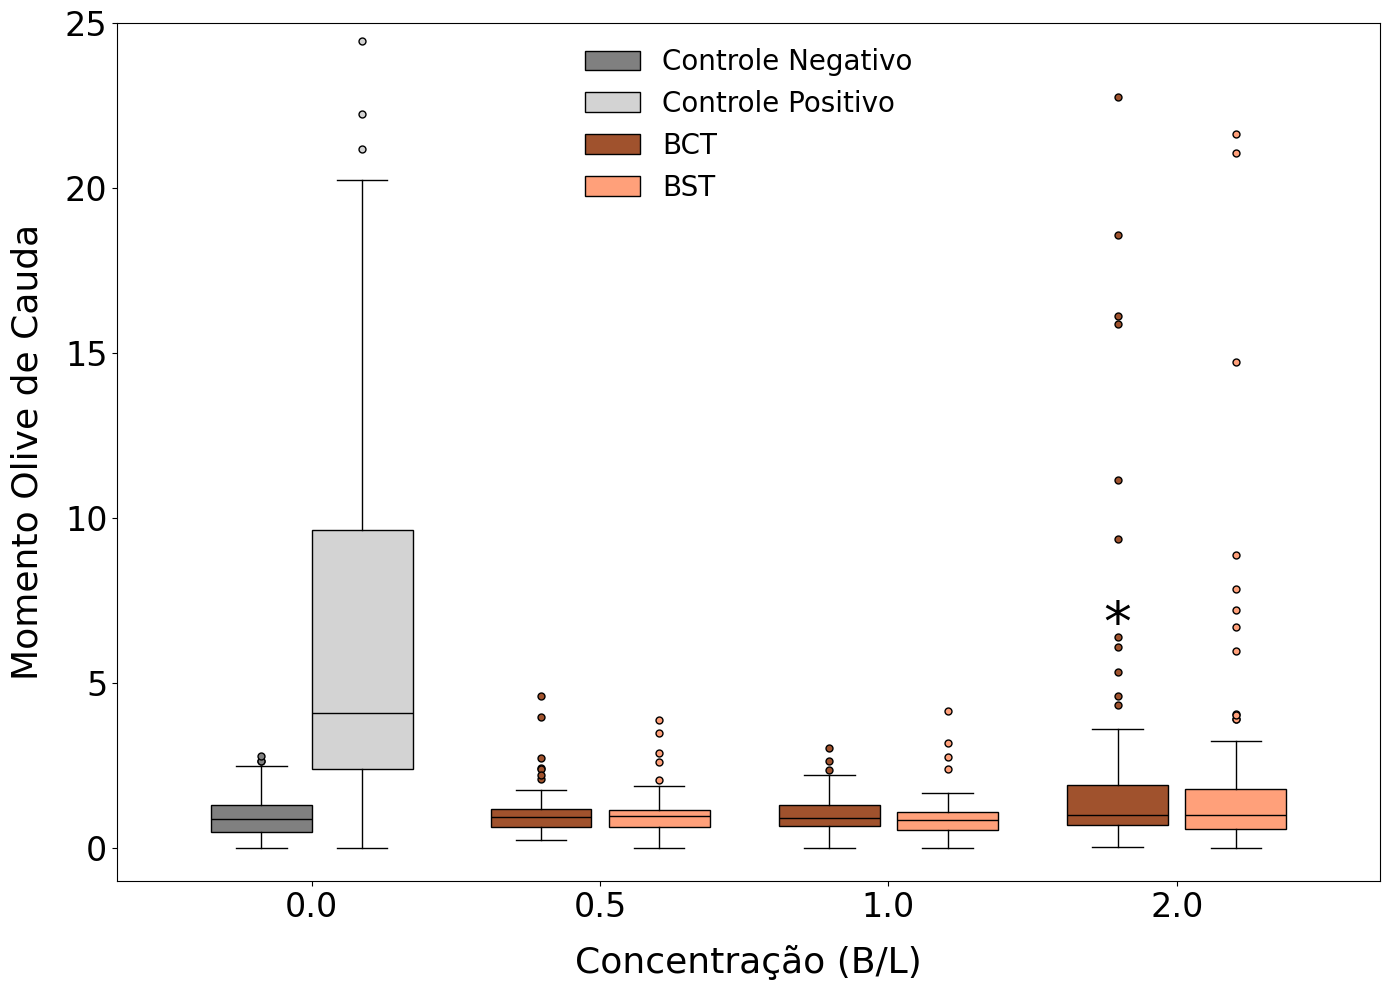

In [197]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_excel("cometa_limpo.xlsx")

# ----------------------------
# Preparação dos dados
# ----------------------------

controls = ['control_negative', 'control_positive']
colors = {
    'control_negative': 'gray',
    'control_positive': 'lightgray',
    'BCT': 'sienna',
    'BST': 'lightsalmon'
}

df['type_low'] = df['type'].str.lower()

controls_data = df[df['type_low'].isin(controls)]
treatments_data = df[~df['type_low'].isin(controls)]

concentrations = sorted(treatments_data['concentration'].unique())
x_labels = ['0.0'] + [str(c) for c in concentrations]
x_pos = np.arange(len(x_labels))

fig, ax = plt.subplots(figsize=(14, 10))
bar_width = 0.35  # largura das caixas
gap = 0.03        # << pequeno espaço extra entre BCT e BST

# ----------------------------
# CONTROLES → ambos na posição x=0
# ----------------------------

base_x = 0

for i, ctrl in enumerate(controls):
    subset = controls_data[controls_data['type_low'] == ctrl]['tail_moment'].values
    x = base_x - bar_width/2 if i == 0 else base_x + bar_width/2

    ax.boxplot(
        subset,
        positions=[x],
        widths=bar_width,
        patch_artist=True,
        boxprops=dict(facecolor=colors[ctrl], color='black'),
        medianprops=dict(color='black'),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),
        flierprops=dict(marker='o', markersize=5, markerfacecolor=colors[ctrl],
                        markeredgecolor='black')
    )

# ----------------------------
# TRATAMENTOS BCT / BST
# ----------------------------

for i, conc in enumerate(concentrations):
    base_x = 1 + i  # controles ocupam posição 0

    # ---------------- BCT ----------------
    bct_vals = treatments_data[
        (treatments_data['type'] == 'BCT') &
        (treatments_data['concentration'] == conc)
    ]['tail_moment'].values

    if len(bct_vals) > 0:
        ax.boxplot(
            bct_vals,
            positions=[(base_x - bar_width/2) - gap],  # << deslocado para esquerda
            widths=bar_width,
            patch_artist=True,
            boxprops=dict(facecolor=colors['BCT'], color='black'),
            medianprops=dict(color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(marker='o', markersize=5, markerfacecolor=colors['BCT'],
                            markeredgecolor='black'),
            labels=['']
        )

    # ---------------- BST ----------------
    bst_vals = treatments_data[
        (treatments_data['type'] == 'BST') &
        (treatments_data['concentration'] == conc)
    ]['tail_moment'].values

    if len(bst_vals) > 0:
        ax.boxplot(
            bst_vals,
            positions=[(base_x + bar_width/2) + gap],  # << deslocado para direita
            widths=bar_width,
            patch_artist=True,
            boxprops=dict(facecolor=colors['BST'], color='black'),
            medianprops=dict(color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(marker='o', markersize=5, markerfacecolor=colors['BST'],
                            markeredgecolor='black'),
            labels=['']
        )

# ----------------------------
# ASTERISCO NO BCT - concentração 2
# ----------------------------

target_conc = 2  # concentração desejada

if target_conc in concentrations:

    i = concentrations.index(target_conc)  # índice da concentração 2
    base_x = 1 + i  # mesma lógica usada no loop

    bct_position = (base_x - bar_width/2) - gap
    
    # pegar valor máximo do BCT para colocar o asterisco acima
    bct_vals = treatments_data[
        (treatments_data['type'] == 'BCT') &
        (treatments_data['concentration'] == target_conc)
    ]['tail_moment'].values

    if len(bct_vals) > 0:
        bct_max = np.max(bct_vals)

        ax.text(
            bct_position,
            bct_max - 67.3,     # altura do asterisco acima da caixa
            '*',
            ha='center',
            va='bottom',
            fontsize=40,
            color='black'
        )


# ----------------------------
# EIXOS
# ----------------------------

ax.set_xlabel('Concentração (B/L)', fontsize=26, labelpad=15)
ax.set_ylabel('Momento Olive de Cauda', fontsize=26, labelpad=15)

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, fontsize=24)

ax.tick_params(axis='y', labelsize=24)

# ----------------------------
# LIMITE Y
# ----------------------------

ax.set_ylim(-1, 25)

# ----------------------------
# LEGENDA
# ----------------------------

import matplotlib.patches as Patch

legend_elements = [
    Patch.Patch(facecolor=colors['control_negative'], edgecolor='black', label='Controle Negativo'),
    Patch.Patch(facecolor=colors['control_positive'], edgecolor='black', label='Controle Positivo'),
    Patch.Patch(facecolor=colors['BCT'], edgecolor='black', label='BCT'),
    Patch.Patch(facecolor=colors['BST'], edgecolor='black', label='BST')
]

leg = ax.legend(handles=legend_elements, fontsize=20, loc='upper center')
leg.get_frame().set_facecolor('none')
leg.get_frame().set_edgecolor('none')

plt.tight_layout()
plt.show()


C:\Users\andre23035\AppData\Local\Temp\ipykernel_25764\979208712.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\andre23035\AppData\Local\Temp\ipykernel_25764\979208712.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\andre23035\AppData\Local\Temp\ipykernel_25764\979208712.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\andre23035\AppData\Local\Temp\ipykernel_25764\979208712.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 

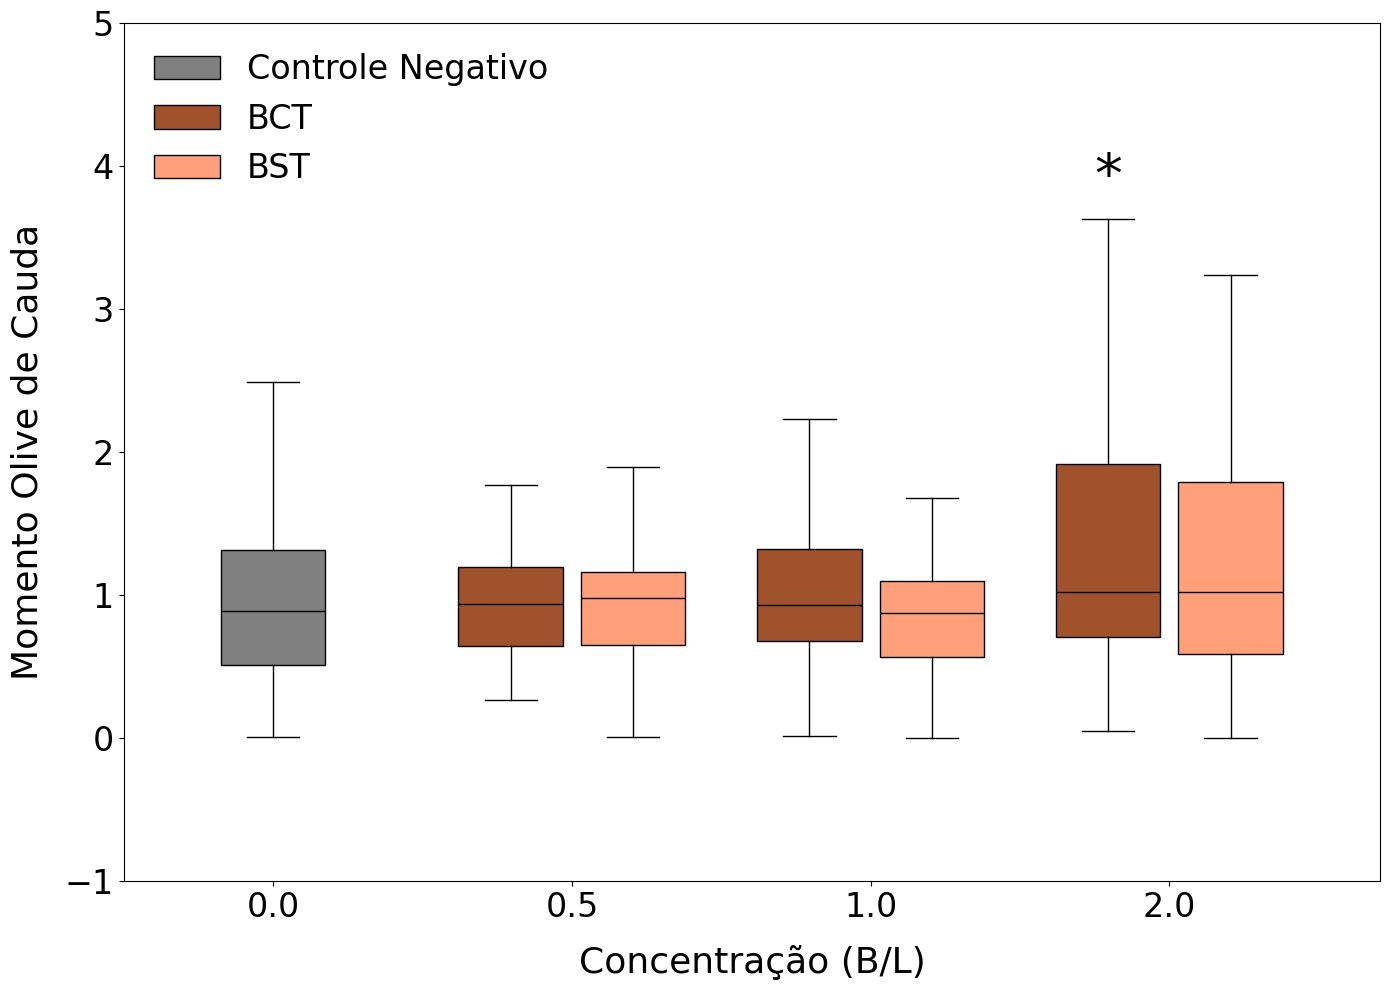

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_excel("cometa_limpo.xlsx")

# ----------------------------
# Preparação dos dados
# ----------------------------

controls = ['control_negative']   # << APENAS controle negativo
colors = {
    'control_negative': 'gray',
    'BCT': 'sienna',
    'BST': 'lightsalmon'
}

df['type_low'] = df['type'].str.lower()

controls_data = df[df['type_low'].isin(controls)]
treatments_data = df[~df['type_low'].isin(['control_negative', 'control_positive'])]

concentrations = sorted(treatments_data['concentration'].unique())
x_labels = ['0.0'] + [str(c) for c in concentrations]
x_pos = np.arange(len(x_labels))

fig, ax = plt.subplots(figsize=(14, 10))
bar_width = 0.35
gap = 0.03    # pequeno espaço entre BCT e BST

# ----------------------------
# CONTROLE NEGATIVO → posição 0
# ----------------------------

base_x = 0

subset = controls_data['tail_moment'].values
ax.boxplot(
    subset,
    positions=[base_x],
    widths=bar_width,
    patch_artist=True,
    showfliers=False,  # << REMOVE OUTLIERS
    boxprops=dict(facecolor=colors['control_negative'], color='black'),
    medianprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

# ----------------------------
# TRATAMENTOS BCT / BST
# ----------------------------

# Vamos armazenar a posição do BCT 2.0
bct20_position = None
bct20_max = None

for i, conc in enumerate(concentrations):
    base_x = 1 + i  # controles ficam na posição 0

    # ---------------- BCT ----------------
    bct_vals = treatments_data[
        (treatments_data['type'] == 'BCT') &
        (treatments_data['concentration'] == conc)
    ]['tail_moment'].values

    if len(bct_vals) > 0:
        pos_bct = (base_x - bar_width/2) - gap
        ax.boxplot(
            bct_vals,
            positions=[pos_bct],
            widths=bar_width,
            patch_artist=True,
            showfliers=False,  # << REMOVE OUTLIERS
            boxprops=dict(facecolor=colors['BCT'], color='black'),
            medianprops=dict(color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            labels=['']
        )

        # Se a concentração for 2.0, gravamos a posição p/ por o asterisco
        if conc == 2.0:
            bct20_position = pos_bct
            bct20_max = np.max(bct_vals)

    # ---------------- BST ----------------
    bst_vals = treatments_data[
        (treatments_data['type'] == 'BST') &
        (treatments_data['concentration'] == conc)
    ]['tail_moment'].values

    if len(bst_vals) > 0:
        ax.boxplot(
            bst_vals,
            positions=[(base_x + bar_width/2) + gap],
            widths=bar_width,
            patch_artist=True,
            showfliers=False,  # << REMOVE OUTLIERS
            boxprops=dict(facecolor=colors['BST'], color='black'),
            medianprops=dict(color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            labels=['']
        )



# ----------------------------
# Adicionar asterisco estatístico no BCT 2.0
# ----------------------------

if bct20_position is not None:
    ax.text(
        bct20_position,
        bct20_max - 69.5,   # distância acima da caixa
        '*',
        ha='center',
        va='bottom',
        fontsize=40,
        color='black'
    )

# ----------------------------
# EIXOS
# ----------------------------

ax.set_xlabel('Concentração (B/L)', fontsize=26, labelpad=15)
ax.set_ylabel('Momento Olive de Cauda', fontsize=26, labelpad=15)

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, fontsize=24)

ax.tick_params(axis='y', labelsize=24)

# ----------------------------
# LIMITE Y
# ----------------------------

ax.set_ylim(-1, 5)

# ----------------------------
# LEGENDA
# ----------------------------

import matplotlib.patches as Patch

legend_elements = [
    Patch.Patch(facecolor=colors['control_negative'], edgecolor='black', label='Controle Negativo'),
    Patch.Patch(facecolor=colors['BCT'], edgecolor='black', label='BCT'),
    Patch.Patch(facecolor=colors['BST'], edgecolor='black', label='BST')
]

leg = ax.legend(handles=legend_elements, fontsize=24, loc='upper left')
leg.get_frame().set_facecolor('none')
leg.get_frame().set_edgecolor('none')

plt.tight_layout()
plt.show()


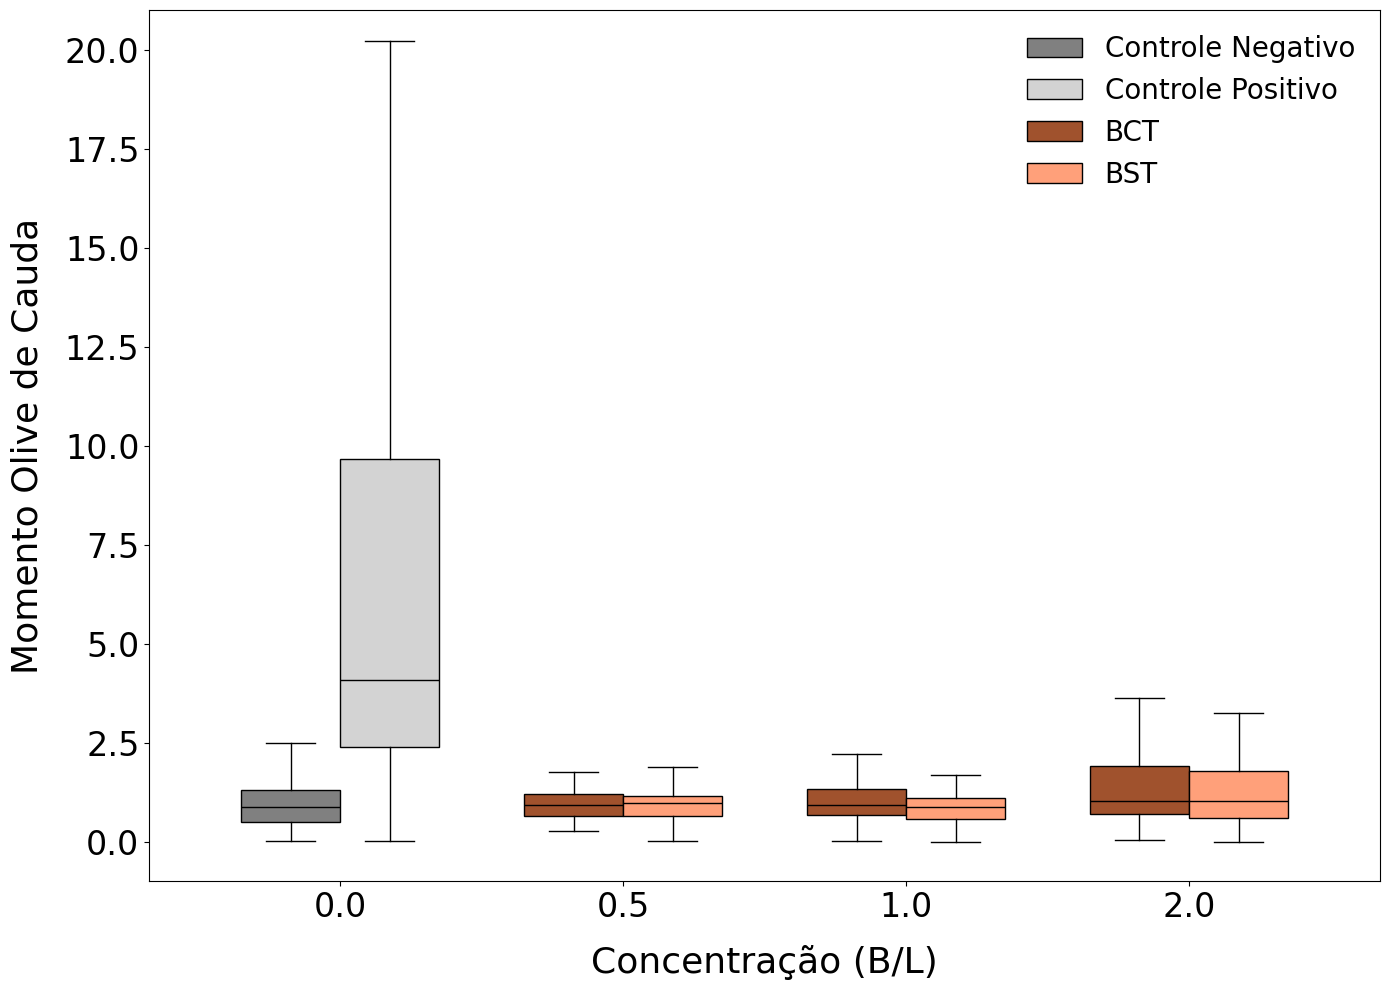

In [174]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_excel("cometa_limpo.xlsx")

# ----------------------------
# Preparação dos dados
# ----------------------------

controls = ['control_negative', 'control_positive']
colors = {
    'control_negative': 'gray',
    'control_positive': 'lightgray',
    'BCT': 'sienna',
    'BST': 'lightsalmon'
}

df['type_low'] = df['type'].str.lower()

controls_data = df[df['type_low'].isin(controls)]
treatments_data = df[~df['type_low'].isin(controls)]

concentrations = sorted(treatments_data['concentration'].unique())
x_labels = ['0.0'] + [str(c) for c in concentrations]
x_pos = np.arange(len(x_labels))

fig, ax = plt.subplots(figsize=(14, 10))
bar_width = 0.35  # usado para deslocar as caixas

# ----------------------------
# CONTROLES → ambos na posição x=0
# ----------------------------

base_x = 0

for i, ctrl in enumerate(controls):
    subset = controls_data[controls_data['type_low'] == ctrl]['tail_moment'].values
    x = base_x - bar_width/2 if i == 0 else base_x + bar_width/2

    bp = ax.boxplot(
        subset,
        positions=[x],
        widths=bar_width,
        patch_artist=True,
        showfliers=False,  # <<< REMOVE OS OUTLIERS
        boxprops=dict(facecolor=colors[ctrl], color='black'),
        medianprops=dict(color='black'),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black')
    )

# ----------------------------
# TRATAMENTOS BCT / BST
# ----------------------------

for i, conc in enumerate(concentrations):
    base_x = 1 + i  # controles ocupam posição 0

    # BCT
    bct_vals = treatments_data[
        (treatments_data['type'] == 'BCT') &
        (treatments_data['concentration'] == conc)
    ]['tail_moment'].values

    if len(bct_vals) > 0:
        ax.boxplot(
            bct_vals,
            positions=[base_x - bar_width/2],
            widths=bar_width,
            patch_artist=True,
            showfliers=False,  # <<< REMOVE OUTLIERS
            boxprops=dict(facecolor=colors['BCT'], color='black'),
            medianprops=dict(color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black')
        )

    # BST
    bst_vals = treatments_data[
        (treatments_data['type'] == 'BST') &
        (treatments_data['concentration'] == conc)
    ]['tail_moment'].values

    if len(bst_vals) > 0:
        ax.boxplot(
            bst_vals,
            positions=[base_x + bar_width/2],
            widths=bar_width,
            patch_artist=True,
            showfliers=False,  # <<< REMOVE OUTLIERS
            boxprops=dict(facecolor=colors['BST'], color='black'),
            medianprops=dict(color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black')
        )

# ----------------------------
# EIXOS
# ----------------------------

ax.set_xlabel('Concentração (B/L)', fontsize=26, labelpad=15)
ax.set_ylabel('Momento Olive de Cauda', fontsize=26, labelpad=15)

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, fontsize=24)

ax.tick_params(axis='y', labelsize=24)

# ----------------------------
# LIMITE Y
# ----------------------------

ax.set_ylim(-1, 21)

# ----------------------------
# LEGENDA
# ----------------------------

import matplotlib.patches as Patch

legend_elements = [
    Patch.Patch(facecolor=colors['control_negative'], edgecolor='black', label='Controle Negativo'),
    Patch.Patch(facecolor=colors['control_positive'], edgecolor='black', label='Controle Positivo'),
    Patch.Patch(facecolor=colors['BCT'], edgecolor='black', label='BCT'),
    Patch.Patch(facecolor=colors['BST'], edgecolor='black', label='BST')
]

leg = ax.legend(handles=legend_elements, fontsize=20)
leg.get_frame().set_facecolor('none')
leg.get_frame().set_edgecolor('none')

plt.tight_layout()
plt.show()
